In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.widgets import RangeSlider
from ipywidgets import interact, IntSlider, SelectionSlider
import requests
import warnings
from adjustText import adjust_text
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, q_stat
from arch.unitroot import PhillipsPerron
import statsmodels.api as smf
from IPython.display import display, Markdown, HTML
from sklearn.decomposition import PCA


warnings.simplefilter("ignore", pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="pandas")

from pricing.pricer import PricerClass
from itertools import combinations
from calibration import Calibration
from tradescreener import tradeScreener
from plotting_utils import residuals_actualFitted, multipleResiduals, actualVsFittedCurve, \
    fittingErrorsHeatmap, threeFactorPlot, twoFactorPlot, factorsForwardsPlot, fittingErrorsHeatmap_fwd, \
    currentErrorsHeatmap_fwd

In [42]:
data = pd.read_csv("data/bankofengland/nominal/bankofengland_gilt_filtered.csv", index_col =0, parse_dates=True)
data = data.drop('0.75', axis=1)

Unfortunately, the 0.75y datapoint is missing for a few weeks in the recent period, so we drop it.

In [43]:
bankrate =pd.read_csv("data/bankofengland/bankrate.csv")
bankrate["Date"] = pd.to_datetime(bankrate["Date"], format="%d %b %y")
bankrate.columns = ['date', 'short']
bankrate.set_index('date', inplace=True)
bankrate.index = pd.to_datetime(bankrate.index)
bankrate.sort_index(inplace=True)

In [44]:
zeroCouponYields = pd.merge(bankrate, data, left_index=True, right_index=True, how = 'inner')
zeroCouponYields.columns = ['short'] + [float(x) for x in zeroCouponYields.columns if x != 'short']
zeroCouponYields.sort_index(inplace=True)

### 1. Calibration from 2014 to 2022, on yields below 25 yrs

We fit on yields from 1 to 5 years in breaks of 6 months and on yields above 5 years in breaks of 1 year. I also tried with the whole term structure in breaks of 6 months but the fit was terrible. 

In [10]:
sampleDates = ('2014-01-01', '2022-01-01')
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 5] + [x for x in range(5, 26)]

cal_2022 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [11]:
print('Calibrating between', termStructurePath.index[0].date(), 'and', termStructurePath.index[-1].date())
print('Using maturities from', cal_2022.maturities[0], 'to', cal_2022.maturities[-1], 'years.')

best_alpha_2022 =cal_2022.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))

best_sigma_2022 = cal_2022.calibrateSigma(alpha_r = best_alpha_2022['alpha_r'], 
                                alpha_m = best_alpha_2022['alpha_m'], 
                                alpha_l = best_alpha_2022['alpha_l'], 
                                initialGuess = [0.01092, 0.00964, 0.212])

best_mu_2022 = cal_2022.calibrateMu(alpha_r = best_alpha_2022['alpha_r'], 
                          alpha_m = best_alpha_2022['alpha_m'], 
                          alpha_l = best_alpha_2022['alpha_l'], 
                          sigma_m = best_sigma_2022['sigma_m'], 
                          sigma_l = best_sigma_2022['sigma_l'], 
                          rho = best_sigma_2022['rho'], 
                          initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')        # REMARK: Calibration here was done with 2y-fwd and 10y-fwd 1-year

Calibrating between 2014-01-02 and 2021-12-31
Using maturities from 1.0 to 25 years.


KeyboardInterrupt: 

#### 1.1 Inspecting calibration fit

In [48]:
empiricalAlpha = np.vstack([x for x in cal_2022.regression()])
modelImpliedAlpha = np.vstack([[cal_2022.alphaComparison(tau = x, alpha_r = best_alpha_2022['alpha_r'], 
                                                         alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'])] for x in cal_2022.maturities])

comparisonDf_2y = pd.DataFrame({'spot maturity': cal_2022.maturities, 'empirical': empiricalAlpha[:, 0], 'model implied': modelImpliedAlpha[:, 0]}).set_index('spot maturity')
comparisonDf_10y = pd.DataFrame({'spot maturity': cal_2022.maturities, 'empirical': empiricalAlpha[:, 1], 'model implied': modelImpliedAlpha[:, 1]}).set_index('spot maturity')

Text(0.5, 0.98, 'Model implied (given best alpha) vs empirical betas from regression')

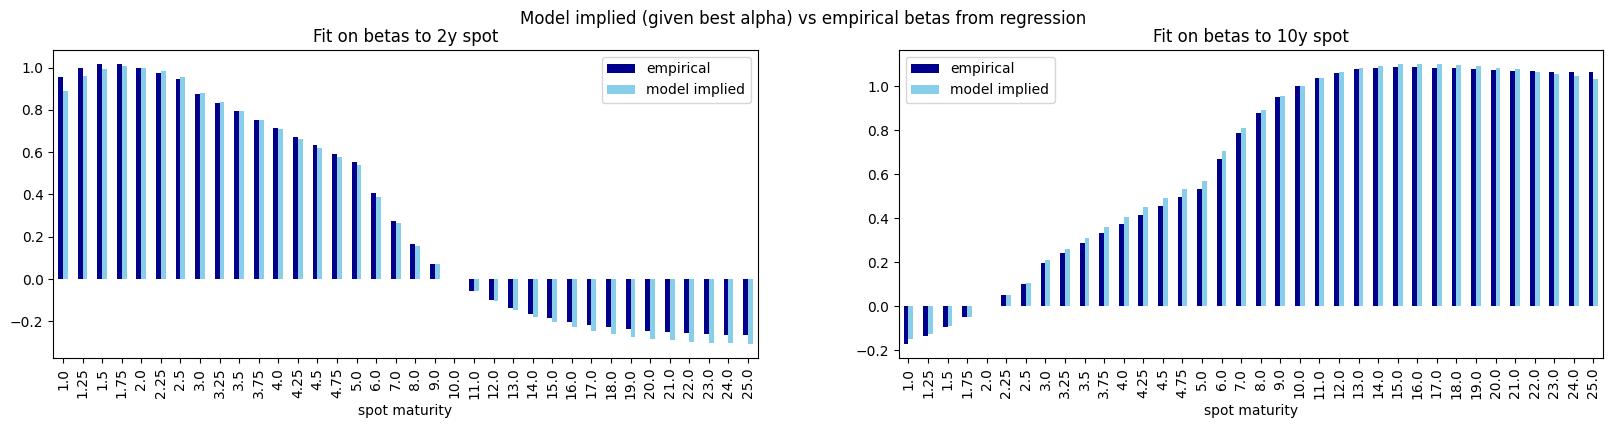

In [49]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (20,4))
comparisonDf_2y.plot(kind = 'bar', ax=ax[0], title = f'Fit on betas to {int(cal_2022.fairly_priced[0])}y spot', color= ['darkblue', 'skyblue'])
comparisonDf_10y.plot(kind = 'bar', ax=ax[1], title = f'Fit on betas to {int(cal_2022.fairly_priced[1])}y spot', color= ['darkblue', 'skyblue'])
fig.suptitle("Model implied (given best alpha) vs empirical betas from regression")

In [50]:
empiricalSigma = np.array([cal_2022.empiricalVariance(tau = x, alpha_r=best_alpha_2022['alpha_r']) for x in cal_2022.maturities])
modelImpliedSigma = np.array([cal_2022.modelImpliedVariance(
    tau = x, alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'], 
    sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho']) for x in cal_2022.maturities])

comparisonDf_sigma = pd.DataFrame({'spot maturity': cal_2022.maturities, 
                                   'empirical': empiricalSigma, 
                                   'model implied': modelImpliedSigma}).set_index('spot maturity')

<Axes: title={'center': 'Fit on variances of each yield'}, xlabel='spot maturity'>

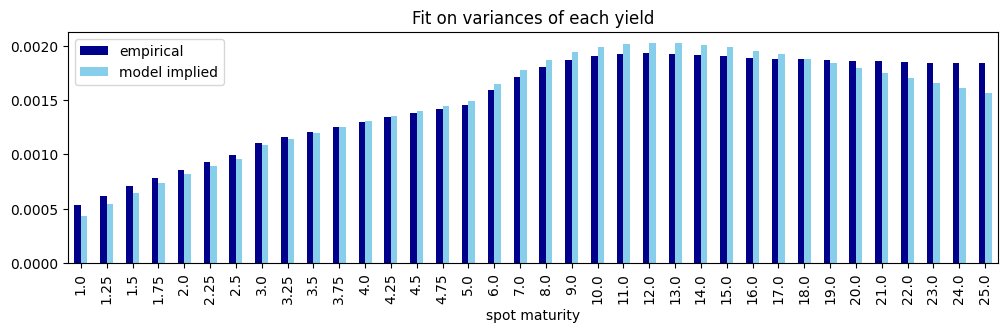

In [51]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (12,3))
comparisonDf_sigma.plot(kind = 'bar', ax=ax, title = f'Fit on variances of each yield', color= ['darkblue', 'skyblue'])

#### 1.2. Inspecting Extrapolated Factors

To get OOS extracted factors, we re-feed the calibration class with the full dataset. We've calibrated all parameters on the in-sample piece of the data, so now we can operate on the full dataset to get OOS results.

In [52]:
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:None]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 5] + [x for x in range(5, 25)]

cal_2022 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [53]:
lf_full_2022 = cal_2022.extractLatentFactors_fwd(alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'], 
                         sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho'], mu = best_mu_2022['mu'])

estFactorsDf_full_2022 = pd.DataFrame(lf_full_2022, columns = ['medium', 'long'], index = zeroCouponYields[sampleDates[0]:None].index)
estFactorsDf_full_2022['short'] = termStructurePath['short']
estFactorsDf_full_2022 = estFactorsDf_full_2022[['short', 'medium', 'long']]
estFactorsDf_full_2022.iloc[-1]

short     3.750000
medium    1.637214
long      7.099623
Name: 2026-03-31 00:00:00, dtype: float64

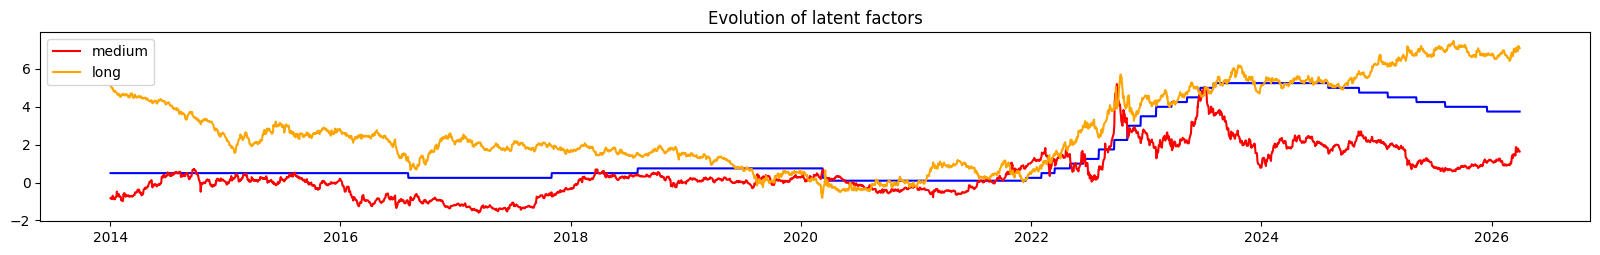

In [54]:
threeFactorPlot(estFactorsDf_full=estFactorsDf_full_2022)

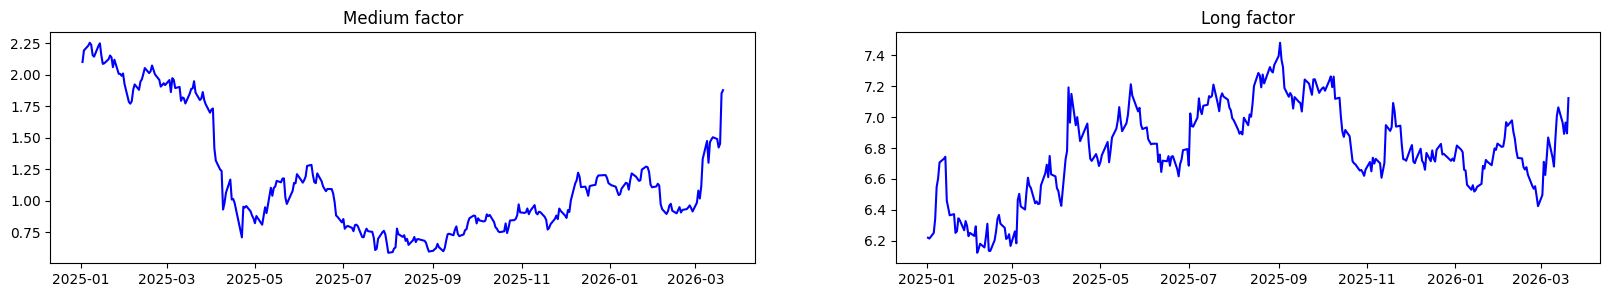

In [55]:
limits = ('2025-01-01', '2026-03-20')
twoFactorPlot(estFactorsDf_full=estFactorsDf_full_2022, limits = limits)

In [ ]:
calParams_2022 = dict(alpha_r = best_alpha_2022['alpha_r'], alpha_m = best_alpha_2022['alpha_m'], alpha_l = best_alpha_2022['alpha_l'],
                  sigma_m = best_sigma_2022['sigma_m'], sigma_l = best_sigma_2022['sigma_l'], rho = best_sigma_2022['rho'], mu = best_mu_2022['mu'])

fittedPricer_2022 = PricerClass(**calParams_2022)
fittedTs_full_2022 = [fittedPricer_2022.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full_2022.iloc[i].values)) for i in range(len(lf_full_2022))]
fittedTs_full_df_2022 = pd.DataFrame(fittedTs_full_2022, columns = MATURITIES, index = pd.to_datetime(estFactorsDf_full_2022.index))
fittedTs_full_df_2022.index = pd.to_datetime(fittedTs_full_df_2022.index)
fittedTs_full_df_2022 - termStructurePath[[col for col in termStructurePath.columns if col in fittedTs_full_df_2022.columns]]

In [153]:
fittingErrors_2022 = fittedTs_full_df_2022 - termStructurePath[[col for col in termStructurePath.columns if col in fittedTs_full_df_2022.columns]].dropna(axis= 1)
fittingErrors_byYear_2022 = (fittingErrors_2022.groupby(fittingErrors_2022.index.year).apply(lambda x: np.sqrt((x**2).mean()).round(5))).T * 100

85.231


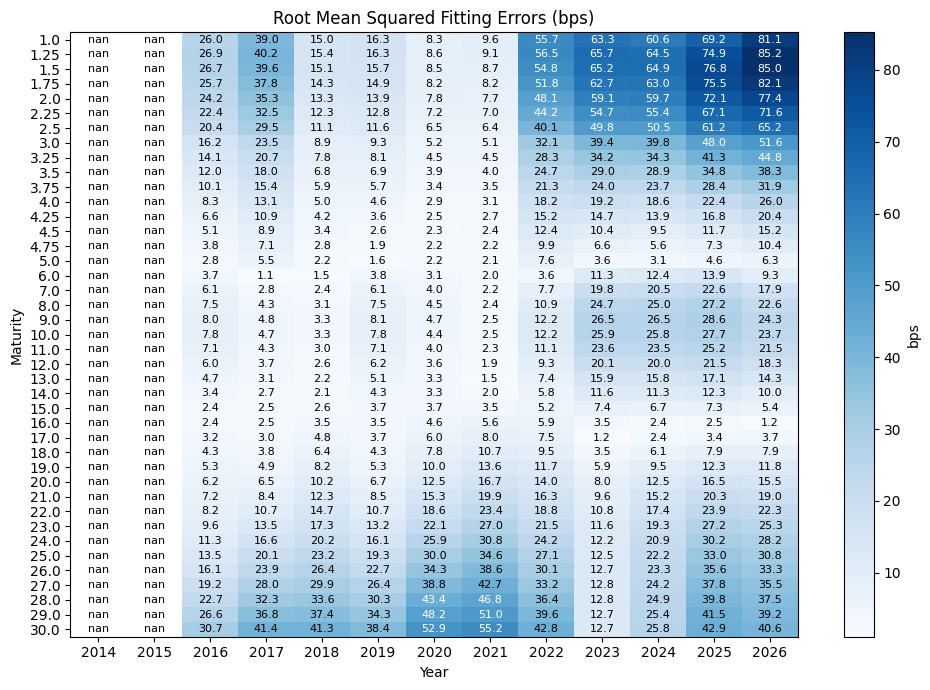

In [156]:
fittingErrorsHeatmap(fittingErrors_byYear=fittingErrors_byYear_2022, figsize = (10, 7))

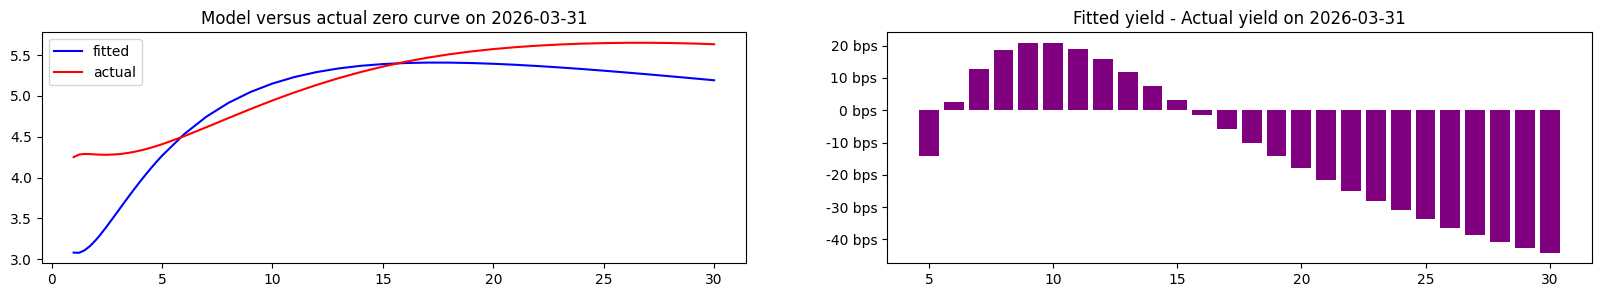

In [157]:
actualVsFittedCurve(targetDate='2026-03-31',
                    fittedTs_full_df=fittedTs_full_df_2022[[x for x in MATURITIES if x in fittedTs_full_df_2022.columns]],
                    termStructurePath=termStructurePath[[x for x in MATURITIES if x in fittedTs_full_df_2022.columns] + ['short']],
                    tenorsAbove=4)

### 2. Calibration from 2016 to 2024, on yields up to 35 yrs

In [45]:
sampleDates = ('2016-01-01', '2024-01-01')
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:sampleDates[1]]
termStructurePath.index = pd.to_datetime(termStructurePath.index)
MATURITIES = [float(x) for x in termStructurePath.columns if x != 'short' and float(x) < 5] + [x for x in range(5, 31)]

print('Using maturities from', MATURITIES[0], 'to', MATURITIES[-1], 'years.')

cal_2024 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

Using maturities from 1.0 to 30 years.


In [46]:
print('Calibrating between', termStructurePath.index[0].date(), 'and', termStructurePath.index[-1].date())
print('Using maturities from', cal_2024.maturities[0], 'to', cal_2024.maturities[-1], 'years.')
best_alpha_2024 =cal_2024.calibrateAlphaSecondStep(grid = np.arange(0.5, 3, 0.01))

best_sigma_2024 = cal_2024.calibrateSigma(alpha_r = best_alpha_2024['alpha_r'], 
                                alpha_m = best_alpha_2024['alpha_m'], 
                                alpha_l = best_alpha_2024['alpha_l'], 
                                initialGuess = [0.01092, 0.00964, 0.212])

best_mu_2024 = cal_2024.calibrateMu(alpha_r = best_alpha_2024['alpha_r'], 
                          alpha_m = best_alpha_2024['alpha_m'], 
                          alpha_l = best_alpha_2024['alpha_l'], 
                          sigma_m = best_sigma_2024['sigma_m'], 
                          sigma_l = best_sigma_2024['sigma_l'], 
                          rho = best_sigma_2024['rho'], 
                          initialGuess = 0.01, lossDecayFactor= 0.8, extraction = 'fwd')        # REMARK: Calibration here was done with 2y-fwd and 10y-fwd 1-year

Calibrating between 2016-01-04 and 2023-12-29
Using maturities from 1.0 to 30 years.
alpha_r: 2.030000000000001, alpha_m: 0.4019179114987534,               alpha_l: 0.015553634578342208, loss: 0.05479934980437952,              success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
sigma_m: 0.084438917243474, sigma_l: 0.07462919813425709, rho: 0.21360838855417247, loss: 2.5662727243848906e-06, success: True, message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
mu: 9.479721172802451, loss: 1894.968289215146, success: True, message: CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH


We fit on yields from 1 to 5 years in breaks of 6 months and on yields above 5 years in breaks of 1 year. I also tried with the whole term structure in breaks of 6 months but the fit was terrible. 

#### 2.1 Inspecting calibration fit

In [49]:
empiricalAlpha = np.vstack([x for x in cal_2024.regression()])
modelImpliedAlpha = np.vstack([[cal_2024.alphaComparison(tau = x, alpha_r = best_alpha_2024['alpha_r'], 
                                                         alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'])] for x in cal_2024.maturities])

comparisonDf_2y = pd.DataFrame({'spot maturity': cal_2024.maturities, 'empirical': empiricalAlpha[:, 0], 'model implied': modelImpliedAlpha[:, 0]}).set_index('spot maturity')
comparisonDf_10y = pd.DataFrame({'spot maturity': cal_2024.maturities, 'empirical': empiricalAlpha[:, 1], 'model implied': modelImpliedAlpha[:, 1]}).set_index('spot maturity')

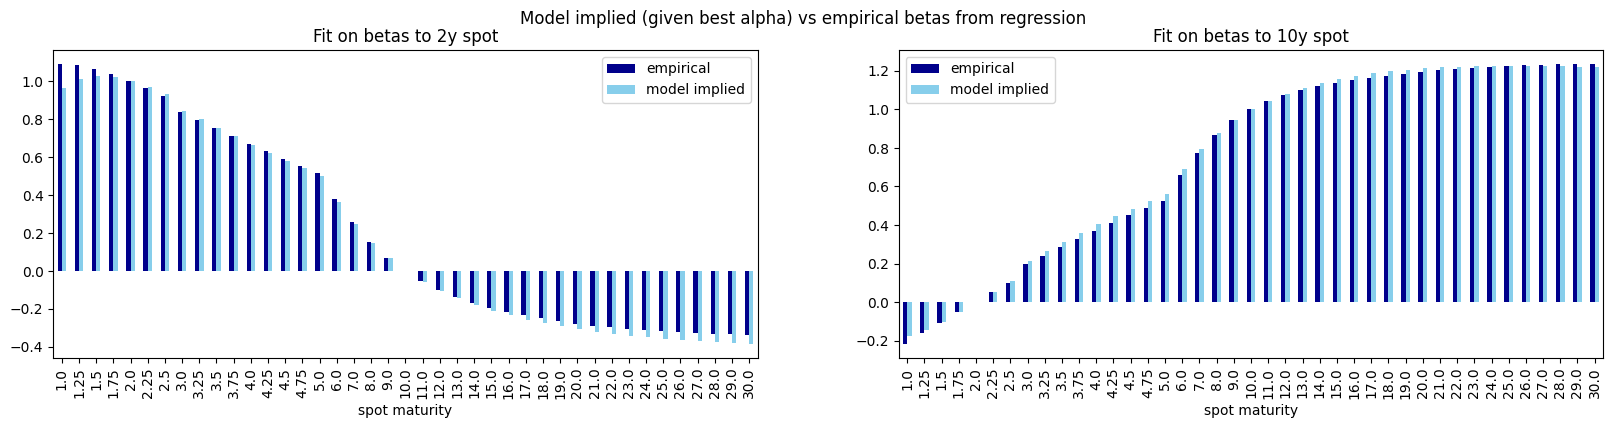

In [50]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (20,4))
comparisonDf_2y.plot(kind = 'bar', ax=ax[0], title = f'Fit on betas to {int(cal_2024.fairly_priced[0])}y spot', color= ['darkblue', 'skyblue'])
comparisonDf_10y.plot(kind = 'bar', ax=ax[1], title = f'Fit on betas to {int(cal_2024.fairly_priced[1])}y spot', color= ['darkblue', 'skyblue'])
fig.suptitle("Model implied (given best alpha) vs empirical betas from regression");

In [51]:
empiricalSigma = np.array([cal_2024.empiricalVariance(tau = x, alpha_r=best_alpha_2024['alpha_r']) for x in cal_2024.maturities])
modelImpliedSigma = np.array([cal_2024.modelImpliedVariance(
    tau = x, alpha_r = best_alpha_2024['alpha_r'], alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'], 
    sigma_m = best_sigma_2024['sigma_m'], sigma_l = best_sigma_2024['sigma_l'], rho = best_sigma_2024['rho']) for x in cal_2024.maturities])

comparisonDf_sigma = pd.DataFrame({'spot maturity': cal_2024.maturities, 
                                   'empirical': empiricalSigma, 
                                   'model implied': modelImpliedSigma}).set_index('spot maturity')

<Axes: title={'center': 'Fit on variances of each yield'}, xlabel='spot maturity'>

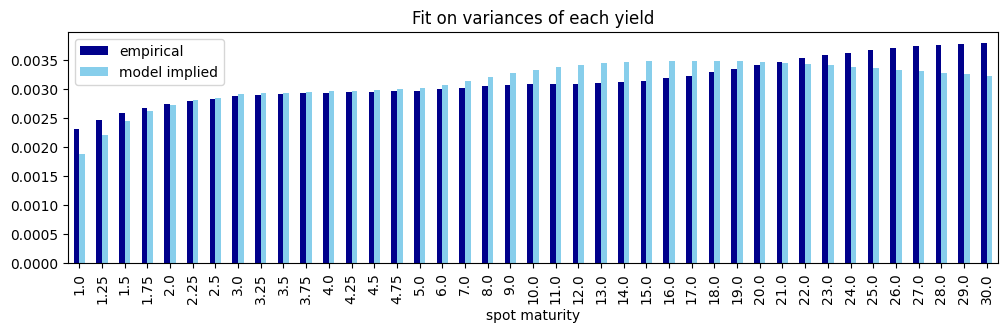

In [52]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (12,3))
comparisonDf_sigma.plot(kind = 'bar', ax=ax, title = f'Fit on variances of each yield', color= ['darkblue', 'skyblue'])

#### 2.2. Inspecting Extrapolated Factors

In [53]:
termStructurePath = zeroCouponYields.copy()[sampleDates[0]:None]
termStructurePath.index = pd.to_datetime(termStructurePath.index)

cal_2024 = Calibration(termStructurePath=termStructurePath[['short'] + MATURITIES], 
                  forwardTermStructurePath=None,
                  allForwardsPath=None,
                  useInputForwards=False,
                  fairly_priced_fwd=[2, 10],
                  fwd_deltaTau= 1,
                  maturities = MATURITIES, fairly_priced=[2, 10])

In [58]:
lf_full_2024 = cal_2024.extractLatentFactors_fwd(alpha_r = best_alpha_2024['alpha_r'], alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'], 
                         sigma_m = best_sigma_2024['sigma_m'], sigma_l = best_sigma_2024['sigma_l'], rho = best_sigma_2024['rho'], mu = best_mu_2024['mu'])

estFactorsDf_full_2024 = pd.DataFrame(lf_full_2024, columns = ['medium', 'long'], index = termStructurePath.index)
estFactorsDf_full_2024['short'] = termStructurePath['short']
estFactorsDf_full_2024 = estFactorsDf_full_2024[['short', 'medium', 'long']]
estFactorsDf_full_2024.iloc[-1]

estFactorsDf_full_2024['2y1y'] = (3 * zeroCouponYields[3] - 2 * zeroCouponYields[1])/1
estFactorsDf_full_2024['10y1y'] = (11 * zeroCouponYields[11] - 10 * zeroCouponYields[10])/1

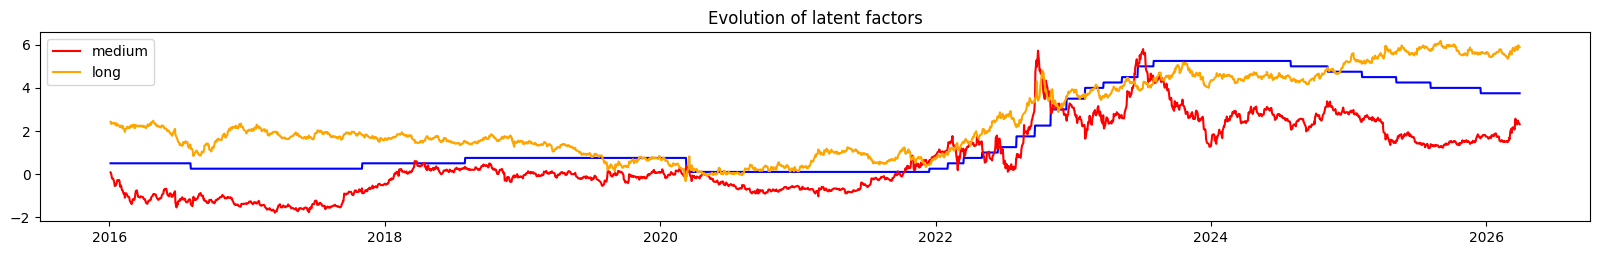

In [55]:
threeFactorPlot(estFactorsDf_full=estFactorsDf_full_2024)

What happened to the factors during the fiscal episodes of 2022?

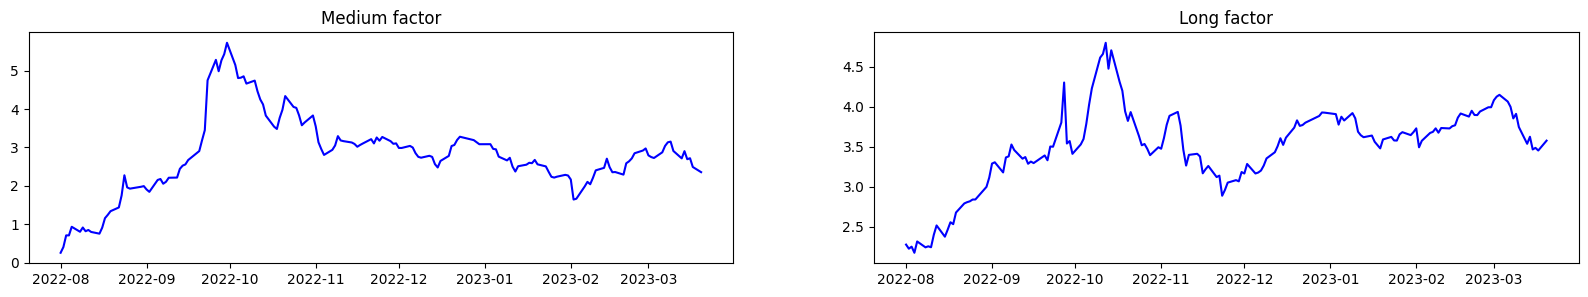

In [56]:
limits = ('2022-08-01', '2023-03-20')
twoFactorPlot(estFactorsDf_full=estFactorsDf_full_2024, limits = limits)

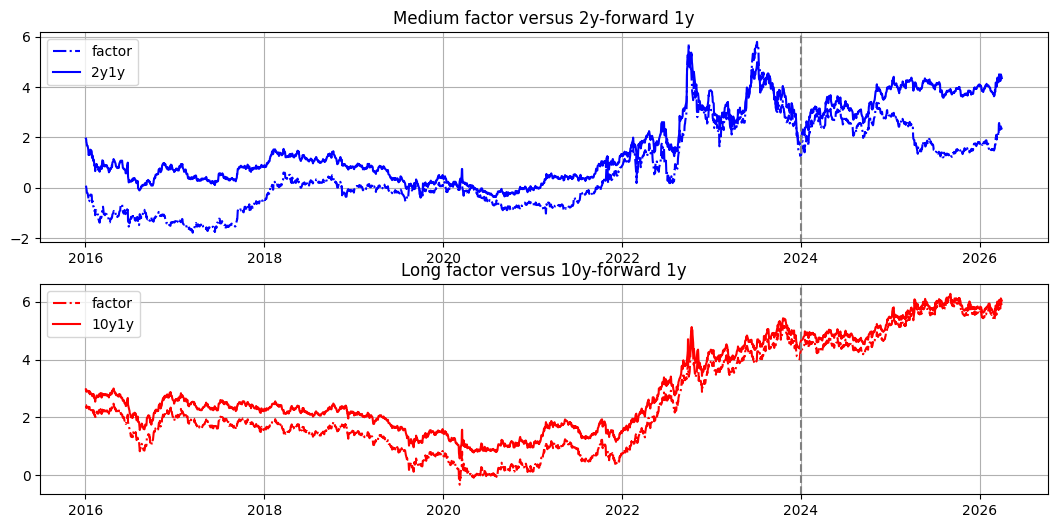

In [59]:
factorsForwardsPlot(estFactorsDf_full=estFactorsDf_full_2024, sampleDates=sampleDates, figsize=(13,6))

In [60]:
calParams_2024 = dict(alpha_r = best_alpha_2024['alpha_r'], alpha_m = best_alpha_2024['alpha_m'], alpha_l = best_alpha_2024['alpha_l'],
                  sigma_m = best_sigma_2024['sigma_m'], sigma_l = best_sigma_2024['sigma_l'], rho = best_sigma_2024['rho'], mu = best_mu_2024['mu'])

fittedPricer_2024 = PricerClass(**calParams_2024)
fittedTs_full_2024 = [fittedPricer_2024.termStructure(maturities = MATURITIES, factors = np.array(estFactorsDf_full_2024.iloc[i].values)) for i in range(len(lf_full_2024))]
fittedTs_full_df_2024 = pd.DataFrame(fittedTs_full_2024, columns = MATURITIES, index = pd.to_datetime(termStructurePath.index))
fittedTs_full_df_2024.index = pd.to_datetime(fittedTs_full_df_2024.index)

fittingErrors_2024 = (fittedTs_full_df_2024 - termStructurePath).dropna(axis= 1)
fittingErrors_byYear_2024 = (fittingErrors_2024.groupby(fittingErrors_2024.index.year).apply(lambda x: np.sqrt((x**2).mean()).round(5))).T * 100

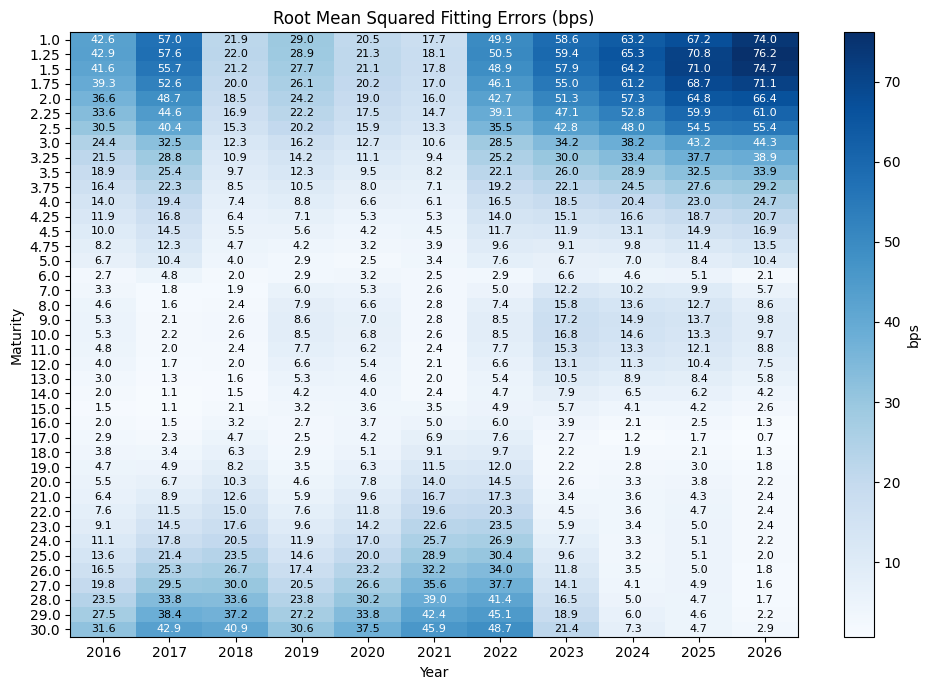

In [61]:
fittingErrorsHeatmap(fittingErrors_byYear=fittingErrors_byYear_2024, figsize = (10, 7))

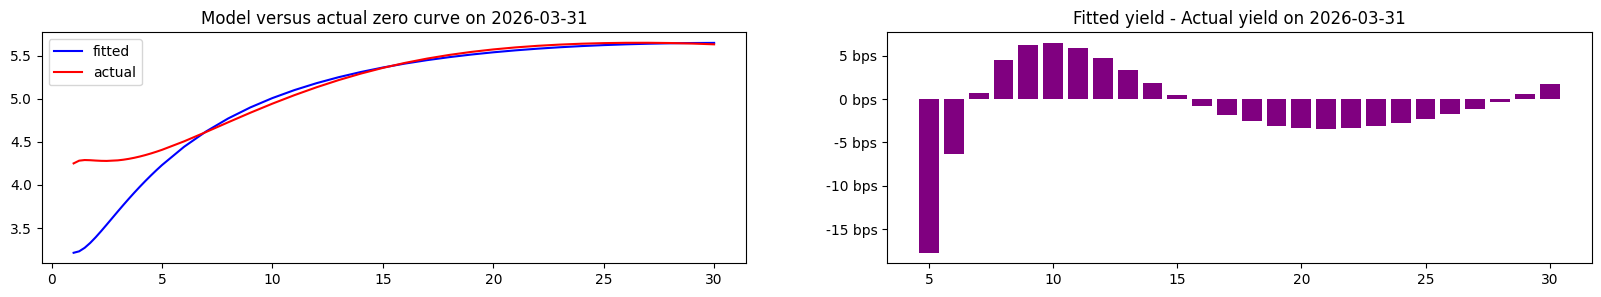

In [62]:
actualVsFittedCurve(targetDate='2026-03-31',
                    fittedTs_full_df=fittedTs_full_df_2024[[x for x in MATURITIES if x in fittedTs_full_df_2024.columns]],
                    termStructurePath=termStructurePath[[x for x in MATURITIES if x in fittedTs_full_df_2024.columns] + ['short']],
                    tenorsAbove=4)

### 3. Models backtest (2016-2024 calibration, 1y-30y)

In [63]:
screen = tradeScreener(modelData = fittedTs_full_df_2024,
                       actualData = zeroCouponYields,
                       maturitySet = [x for x in cal_2024.maturities if int(x) > 0],
                       modelData_fwd= fittedTs_full_df_2024,         # PLEASE FEED FORWARDS IF YOU WANT TO SCREEN FOR FORWARDS
                       actualData_fwd= fittedTs_full_df_2024,
                       maturitySet_fwd=None)

In [64]:
outrightScreen = screen.outrightScreener(shortW = 5, longW = 40, zScoreW = 14)
slopeScreen = screen.slopeScreener(shortW = 5, longW = 40, zScoreW = 14)
flyScreen = screen.flyScreener(shortW = 5, longW = 40, zScoreW = 14)
# fwdScreen = screen.outrightScreener_fwd()

slopeDict = screen.buildSlopes()
flyDict = screen.buildFlies()

backtestParams = dict(
    startDt='2022-01-01', 
    endDt=None,
    shortW = 5, 
    longW = 40, 
    standardW=14,
    numberSigma = 1,
    stopLossSigma = 1,
    stopLossAboveEntry = True
)

allOutrightBacktest = screen.allOutrightBacktest(**backtestParams)
allSlopeBacktest = screen.allSlopesBacktest(**backtestParams)
allFliesBacktest = screen.allFliesBacktest(**backtestParams)

topSlopes = allSlopeBacktest.round(3).sort_values(by='hitrate').tail(10).set_index('slope')
botSlopes = allSlopeBacktest.round(3).sort_values(by='hitrate').head(10).set_index('slope')
topFlies = allFliesBacktest.round(3).sort_values(by='hitrate').tail(10).set_index('fly')
botFlies = allFliesBacktest.round(3).sort_values(by='hitrate').head(10).set_index('fly')

In [65]:
overallHitRate = sum([(bt['hitrate'] * bt['n_trades']).sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])/sum([bt['n_trades'].sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])
overallSkew = sum([(bt['skew'] * bt['n_trades']).sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])/sum([bt['n_trades'].sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])
overallStop = sum([(bt['stop'] * bt['n_trades']).sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])/sum([bt['n_trades'].sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]])
print(f'{"Strategy": <20} {"Tot Hit Rate": <20} {"Tot Skew": <20} {"Stop Triggered": <20} {"Tot Trades": <20}')
print('----'*25)
for backtest, name in zip([allOutrightBacktest, allSlopeBacktest, allFliesBacktest], ['Outrights', 'Slopes', 'Flies']):
    hr = (backtest['hitrate'] * backtest['n_trades'] / backtest['n_trades'].sum()).sum()
    sk = (backtest['skew'] * backtest['n_trades'] / backtest['n_trades'].sum()).sum()
    stop = (backtest['stop'] * backtest['n_trades'] / backtest['n_trades'].sum()).sum()
    n = backtest['n_trades'].sum()
    
    print(f'{f'{name}:': <20} {hr.round(4): <20}  {sk.round(4): <20} {stop.round(4): <20} {n: <20}')
print('----'*25)
print(f'{"Overall:": <20} {overallHitRate.round(4): <20}  {overallSkew.round(4): <20} {overallStop.round(4): <20} {sum([bt["n_trades"].sum() for bt in [allOutrightBacktest, allSlopeBacktest, allFliesBacktest]]): <20}')

    


Strategy             Tot Hit Rate         Tot Skew             Stop Triggered       Tot Trades          
----------------------------------------------------------------------------------------------------
Outrights:           0.5139                1.2944               0.4861               3156                
Slopes:              0.4751                1.301                0.5249               50115               
Flies:               0.4942                1.3711               0.5058               15848               
----------------------------------------------------------------------------------------------------
Overall:             0.4813                1.3168               0.5187               69119               


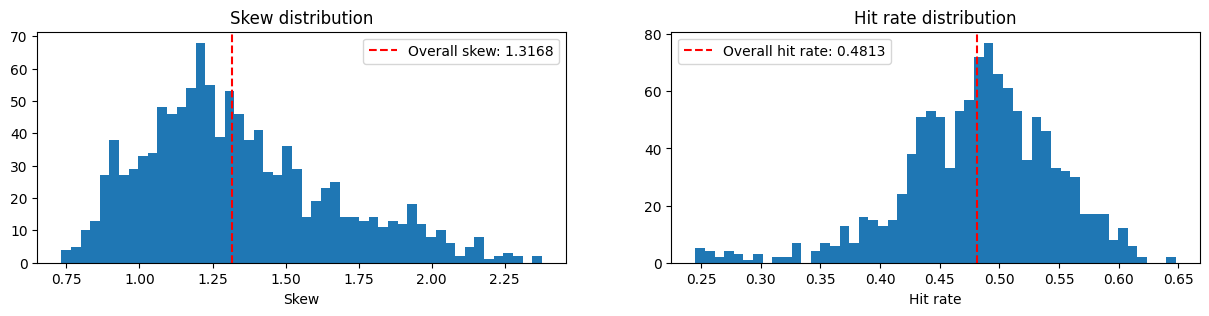

In [32]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 3))

ax[0].hist(pd.concat([allOutrightBacktest.dropna(), allSlopeBacktest.dropna(), allFliesBacktest.dropna()])['skew'], bins = 50);
ax[0].set_title('Skew distribution')
ax[0].set_xlabel('Skew')
ax[0].axvline(overallSkew, color = 'red', linestyle = '--', label = f'Overall skew: {overallSkew.round(4)}');
ax[0].legend()
ax[1].hist(pd.concat([allOutrightBacktest.dropna(), allSlopeBacktest.dropna(), allFliesBacktest.dropna()])['hitrate'], bins = 50);
ax[1].set_title('Hit rate distribution')
ax[1].set_xlabel('Hit rate')
ax[1].axvline(overallHitRate, color = 'red', linestyle = '--', label = f'Overall hit rate: {overallHitRate.round(4)}')
ax[1].legend();

In [67]:
def bucket(x):
    if x < 5:
        return 'frontend'
    elif x >= 5 and x <= 15:
        return 'mid'
    elif x > 15 and x < 24:
        return 'long'
    else:
        return 'ultralong'

allSlopeBacktest['leg1bucket'] = allSlopeBacktest['slope'].apply(lambda x: x.split('s')[0]).apply(lambda x: bucket(float(x)))
allSlopeBacktest['leg2bucket'] = allSlopeBacktest['slope'].apply(lambda x: x.split('s')[1]).apply(lambda x: bucket(float(x)))

order = ['frontend', 'mid', 'long', 'ultralong']
hitRateRecap = allSlopeBacktest.groupby(['leg1bucket', 'leg2bucket'])['hitrate'].mean().unstack().round(4)
hitRateRecap = hitRateRecap.reindex(index=order, columns=order)

skewRecap = allSlopeBacktest.groupby(['leg1bucket', 'leg2bucket'])['skew'].mean().unstack().round(4)
skewRecap = skewRecap.reindex(index=order, columns=order)

In [68]:
hitRateRecap

leg2bucket,frontend,mid,long,ultralong
leg1bucket,,,,
frontend,0.5137,0.5255,0.4702,0.4497
mid,NaN,0.4765,0.5026,0.4537
long,NaN,NaN,0.4642,0.3884
ultralong,NaN,NaN,NaN,0.2950


In [70]:
(1-0.2950)/0.2950

2.3898305084745766

In [69]:
skewRecap

leg2bucket,frontend,mid,long,ultralong
leg1bucket,,,,
frontend,1.3799,1.3067,1.1493,1.2282
mid,NaN,1.1262,1.1910,1.2707
long,NaN,NaN,1.9207,1.8915
ultralong,NaN,NaN,NaN,1.5525


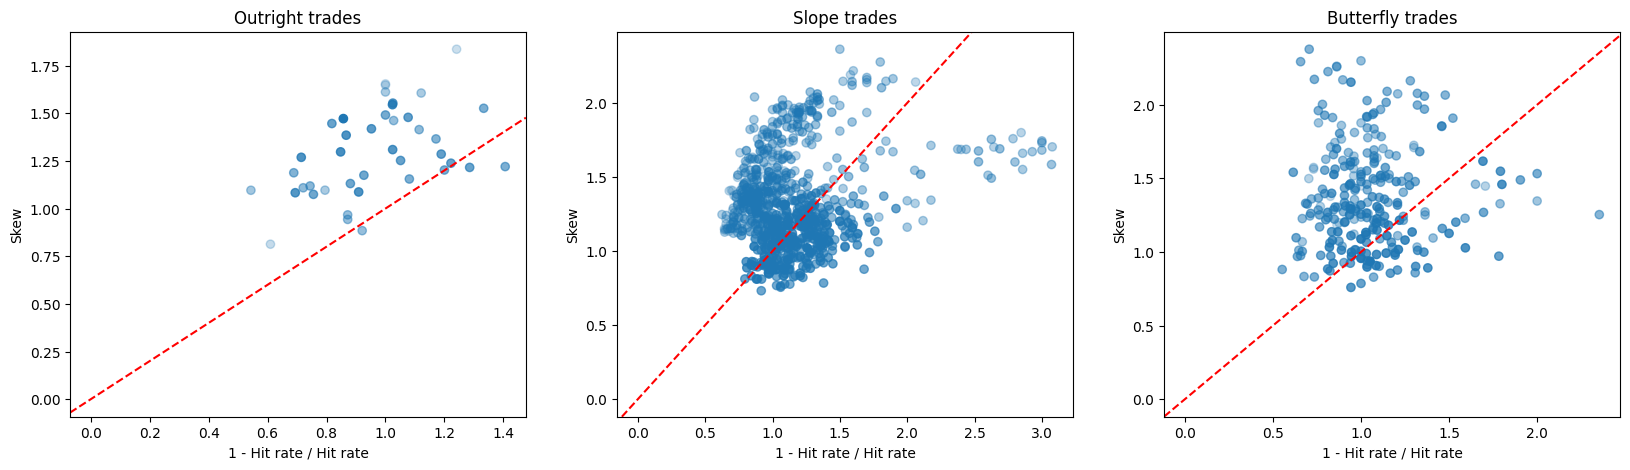

In [36]:

cleanDf = pd.concat([allOutrightBacktest.dropna(), allSlopeBacktest.dropna(), allFliesBacktest.dropna()]).fillna(0)
cleanDf['trade_type'] = np.select([cleanDf['fly'] != 0, cleanDf['slope'] != 0],['butterfly','slope'],default='outright')

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 5))
for i, trade_type in enumerate(['outright', 'slope', 'butterfly']):
    subset = cleanDf[cleanDf['trade_type'] == trade_type]
    n = subset['n_trades']
    alpha = 0.2 + 0.8 * (n - n.min()) / (n.max() - n.min())
    subset = cleanDf[cleanDf['trade_type'] == trade_type]
    ax[i].scatter(subset['hitrate'].apply(lambda x: (1 - x)/x), subset['skew'], alpha = alpha)
    ax[i].axline((0, 0), (1,1), color = 'red', linestyle = '--')
    ax[i].set_title(f'{trade_type.capitalize()} trades')
    ax[i].set_xlabel('1 - Hit rate / Hit rate')
    ax[i].set_ylabel('Skew')
    

#### 3.1. General stats on top 10/worst 10 trades

In [37]:
display(Markdown("### Backtest of predictions on outright tenors\n\n" + 
    allOutrightBacktest.set_index('maturity').T.to_markdown(floatfmt=".3f")))

### Backtest of predictions on outright tenors

|             |    1.0 |   1.25 |    1.5 |   1.75 |    2.0 |   2.25 |    2.5 |    3.0 |   3.25 |    3.5 |   3.75 |    4.0 |   4.25 |    4.5 |   4.75 |    5.0 |    6.0 |    7.0 |    8.0 |    9.0 |   10.0 |   11.0 |   12.0 |   13.0 |   14.0 |   15.0 |   16.0 |   17.0 |   18.0 |   19.0 |   20.0 |   21.0 |   22.0 |   23.0 |   24.0 |   25.0 |   26.0 |   27.0 |   28.0 |   29.0 |   30.0 |
|:------------|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|
| hitrate     |  0.500 |  0.500 |  0.500 |  0.446 |  0.471 |  0.493 |  0.473 |  0.461 |  0.429 |  0.416 |  0.438 |  0.450 |  0.457 |  0.455 |  0.481 |  0.521 |  0.494 |  0.487 |  0.532 |  0.581 |  0.534 |  0.534 |  0.592 |  0.573 |  0.648 |  0.621 |  0.557 |  0.570 |  0.590 |  0.583 |  0.550 |  0.538 |  0.494 |  0.481 |  0.494 |  0.500 |  0.512 |  0.536 |  0.541 |  0.524 |  0.519 |
| skew        |  1.654 |  1.648 |  1.611 |  1.835 |  1.606 |  1.461 |  1.414 |  1.365 |  1.526 |  1.220 |  1.216 |  1.238 |  1.286 |  1.202 |  1.155 |  0.884 |  1.309 |  1.252 |  1.131 |  1.109 |  0.943 |  0.967 |  1.188 |  1.118 |  1.096 |  0.813 |  1.096 |  1.074 |  1.083 |  1.269 |  1.446 |  1.472 |  1.545 |  1.478 |  1.553 |  1.491 |  1.418 |  1.385 |  1.297 |  1.087 |  1.175 |
| avg days    |  5.750 |  4.015 |  3.700 |  3.769 |  3.257 |  2.890 |  2.838 |  2.276 |  2.169 |  1.948 |  1.850 |  1.800 |  1.802 |  1.805 |  1.766 |  1.767 |  1.771 |  1.788 |  1.797 |  1.662 |  1.630 |  1.616 |  1.579 |  1.573 |  1.563 |  1.515 |  1.514 |  1.608 |  1.542 |  1.679 |  1.712 |  1.780 |  1.765 |  1.815 |  1.901 |  1.769 |  2.061 |  2.095 |  2.082 |  2.012 |  2.114 |
| median days |  4.000 |  3.000 |  2.500 |  2.000 |  2.000 |  2.000 |  2.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |  1.000 |
| n_trades    | 64.000 | 66.000 | 70.000 | 65.000 | 70.000 | 73.000 | 74.000 | 76.000 | 77.000 | 77.000 | 80.000 | 80.000 | 81.000 | 77.000 | 77.000 | 73.000 | 83.000 | 80.000 | 79.000 | 74.000 | 73.000 | 73.000 | 76.000 | 75.000 | 71.000 | 66.000 | 70.000 | 79.000 | 83.000 | 84.000 | 80.000 | 91.000 | 85.000 | 81.000 | 81.000 | 78.000 | 82.000 | 84.000 | 85.000 | 84.000 | 79.000 |
| stop        |  0.500 |  0.500 |  0.500 |  0.554 |  0.529 |  0.507 |  0.527 |  0.539 |  0.571 |  0.584 |  0.562 |  0.550 |  0.543 |  0.545 |  0.519 |  0.479 |  0.506 |  0.512 |  0.468 |  0.419 |  0.466 |  0.466 |  0.408 |  0.427 |  0.352 |  0.379 |  0.443 |  0.430 |  0.410 |  0.417 |  0.450 |  0.462 |  0.506 |  0.519 |  0.506 |  0.500 |  0.488 |  0.464 |  0.459 |  0.476 |  0.481 |

In [26]:
html = f"""
<div style="display:flex; gap:40px;">
  <div><h2>Top 10 Curve trades by hit rate</h2>{topSlopes.T.to_html()}</div>
  <div><h2>Worst 10 Curve trades by hit rate</h2>{botSlopes.T.to_html()}</div>
</div>
"""
display(HTML(html))

slope,5s10s,3.25s7s,3.25s5s,3.5s4.5s,3.5s5s,4.0s4.5s,3.25s4.75s,3.25s8s,3.0s8s,3.0s6s
hitrate,0.667,0.667,0.667,0.667,0.667,0.667,0.667,0.692,0.692,0.692
skew,2.082782,3.765522,3.782446,3.737087,3.954645,3.988601,3.657083,5.178435,5.107892,3.967191
avg days,3.4,7.333,11.0,11.0,8.083,8.083,11.0,7.231,7.308,9.538
median days,3.0,6.5,8.0,8.0,7.0,7.0,8.0,6.0,6.0,7.0
n_trades,15,12,12,12,12,12,12,13,13,13
stop,0.333,0.333,0.333,0.333,0.333,0.333,0.333,0.308,0.308,0.308
slope,21s28s,24s25s,23s26s,22s27s,19s28s,11s30s,12s30s,22s25s,20s27s,21s26s
hitrate,0.0,0.0,0.0,0.0,0.05,0.05,0.053,0.053,0.053,0.053
skew,<NA>,<NA>,<NA>,<NA>,2.390075,4.276117,4.009885,2.567658,2.529095,2.542234
avg days,2.562,2.579,2.667,2.667,2.9,2.6,4.105,2.579,2.789,2.579


In [27]:
html = f"""
<div style="display:flex; gap:40px;">
  <div><h2>Top 10 Fly trades by hit rate</h2>{topFlies.T.to_html()}</div>
  <div><h2>Worst 10 Fly trades by hit rate</h2>{botFlies.T.to_html()}</div>
</div>
"""
display(HTML(html))

fly,7s10s13s,12s19s26s,6s11s16s,6s12s18s,15s22s29s,4.0s6s8s,7s9s11s,8s9s10s,6s10s14s,5s11s17s
hitrate,0.545,0.545,0.562,0.562,0.588,0.600,0.615,0.615,0.625,0.647
skew,2.790,1.546,1.452,1.344,4.292,1.849,1.950,2.005,2.233,1.483
avg days,5.091,5.091,3.875,4.375,4.941,8.700,5.462,5.000,5.188,5.059
median days,3.000,4.000,2.500,2.000,4.000,8.000,3.000,1.000,5.000,3.000
n_trades,11.000,11.000,16.000,16.000,17.000,10.000,13.000,13.000,16.000,17.000
stop,0.545,0.545,0.500,0.500,0.529,0.400,0.462,0.462,0.438,0.471
fly,1.0s11s21s,8s17s26s,14s17s20s,11s17s23s,10s17s24s,13s17s21s,12s17s22s,1.0s10s19s,1.5s3.25s5s,15s20s25s
hitrate,0.059,0.067,0.071,0.083,0.083,0.083,0.083,0.105,0.125,0.143
skew,2.499,2.934,4.240,4.350,4.083,4.924,4.766,2.532,1.212,0.533
avg days,3.000,3.533,4.214,4.500,3.417,4.583,4.500,3.316,3.750,4.643


#### 3.2. Attractive outright trades right now

Text(0.5, 1.0, 'Outright trade screener')

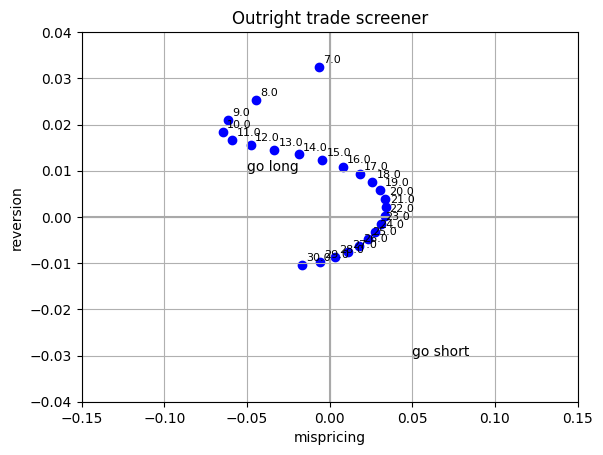

In [82]:
plt.axhline(y = 0, color = 'darkgrey')
plt.axvline(x = 0, color = 'darkgrey')
plt.scatter(outrightScreen['error'], outrightScreen['signal'], color = 'blue')
for i, txt in enumerate(outrightScreen.index):
    plt.annotate(txt,
                 (outrightScreen['error'].iloc[i], outrightScreen['signal'].iloc[i]),
                 xytext=(3,3),
                 textcoords='offset points',
                 fontsize=8)
plt.annotate(text = 'go short', xy = (0.05, - 0.03))
plt.annotate(text = 'go long', xy = (-0.05, + 0.01))
plt.xlim(-0.15, 0.15)
plt.ylim(-0.04, +0.04)
plt.xlabel('mispricing')
plt.ylabel('reversion')
plt.grid(True)
plt.title('Outright trade screener')

We generally trade stuff with zscore above 2. Is there anything around that value?

In [83]:
outrightScreen.loc[outrightScreen['zscore'].abs() > 1.5]

,model,actual,error,signal,rollMean,rollStd,zscore
8.0,4.772465,4.727879,-0.044586,0.025394,-0.070235,0.016184,1.584804
9.0,4.900177,4.838516,-0.061660,0.021015,-0.086126,0.014549,1.681573
10.0,5.008923,4.944189,-0.064734,0.018331,-0.087548,0.013250,1.721800
11.0,5.102039,5.043190,-0.058849,0.016665,-0.079589,0.012046,1.721800
12.0,5.182187,5.134612,-0.047575,0.015522,-0.065955,0.010839,1.695740
13.0,5.251489,5.217963,-0.033525,0.014548,-0.049422,0.009593,1.657059
14.0,5.311635,5.292961,-0.018675,0.013515,-0.032123,0.008304,1.619579
15.0,5.363983,5.359482,-0.004502,0.012305,-0.015659,0.006992,1.595732
16.0,5.409625,5.417605,0.007980,0.010892,-0.001121,0.005734,1.587125
17.0,5.449447,5.467599,0.018152,0.009295,0.010843,0.004693,1.557320


   entry_date  exit_date   side  entry_actual  exit_actual  entry_misp  exit_misp  entry_signal  exit_signal   entry_z    exit_z   stop       reason       pnl  days    hit
1  2023-01-11 2023-01-12   LONG      3.464195     3.416350   -0.111532  -0.099183     -0.014621     0.001792  2.079145  2.710910  False  take_profit  0.047845     1   True
2  2023-02-02 2023-02-03  SHORT      3.101136     3.162001   -0.161197  -0.159437      0.021083     0.009198 -3.043580 -2.939718  False  take_profit  0.060866     1   True
3  2023-04-05 2023-04-11   LONG      3.403974     3.498085   -0.138626  -0.119794     -0.004321     0.010260  2.040257  3.004384   True    stop_loss -0.094111     6  False
4  2023-07-14 2023-07-17   LONG      4.337083     4.361691   -0.203733  -0.188758     -0.023366    -0.011837  2.111158  2.933589   True    stop_loss -0.024608     3  False
5  2023-08-03 2023-08-04  SHORT      4.389891     4.326946   -0.209313  -0.208049      0.014893     0.012709 -2.287929 -2.108909   True    s

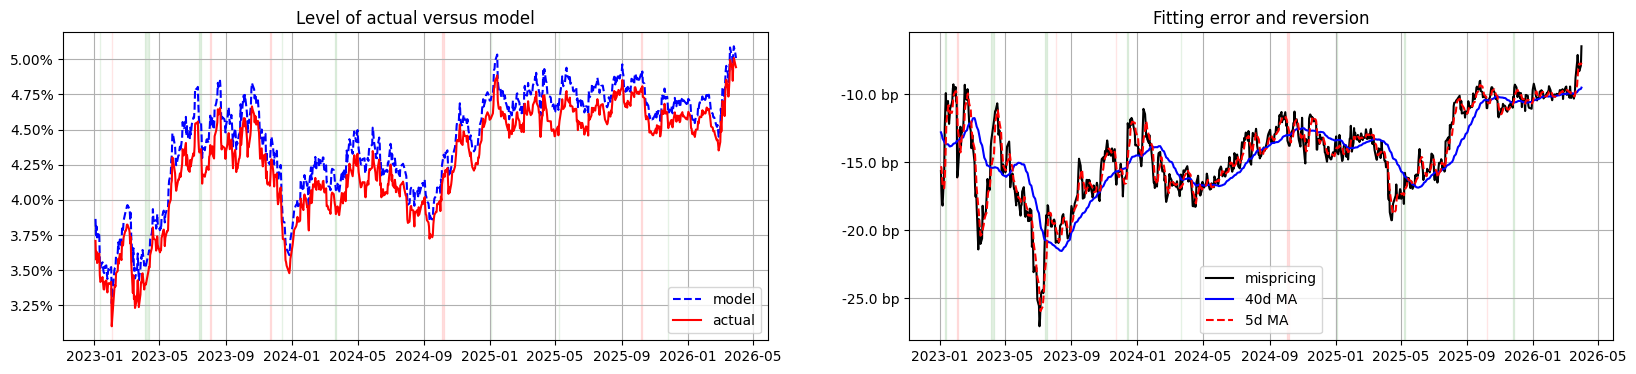

In [84]:
targetTenor = 10
displayStart = '2023-01-01'

bt = screen.singleItemPerformance(modelSeries=screen.modelData[targetTenor],
                                  actualSeries=screen.actualData[targetTenor],
                                  **backtestParams)

print(bt.loc[bt['entry_date'] >= displayStart].to_string())

screen.plotModelVsActual(modelSeries=screen.modelData[targetTenor],
                         actualSeries = screen.actualData[targetTenor],
                         shortW = 5, longW = 40, standardW = 14, leftPlotBp = False,
                         startDt = '2022-01-01', endDt = None,
                         display_startDt= displayStart, display_endDt=None, backtestDf=bt)

#### 3.3. Attractive curve trades right now

In [41]:
slopeScreen.loc[slopeScreen['zscore'].abs() > 1.5].sort_values('zscore')

,model,actual,error,signal,rollMean,rollStd,zscore
12s13s,0.069301,0.083351,0.014050,-0.000973,0.016533,0.001261,-1.968142
11s13s,0.149449,0.174773,0.025324,-0.002116,0.030167,0.002475,-1.957282
11s12s,0.080148,0.091422,0.011274,-0.001143,0.013634,0.001215,-1.942560
11s14s,0.209596,0.249770,0.040174,-0.003150,0.047466,0.003792,-1.923259
12s14s,0.129448,0.158349,0.028901,-0.002007,0.033832,0.002585,-1.907364
10s13s,0.242565,0.273774,0.031209,-0.003783,0.038126,0.003673,-1.883157
10s14s,0.302712,0.348771,0.046059,-0.004816,0.055425,0.004988,-1.877762
11s15s,0.261944,0.316292,0.054347,-0.004359,0.063930,0.005183,-1.849073
13s14s,0.060147,0.074997,0.014851,-0.001033,0.017299,0.001330,-1.840831
10s12s,0.173264,0.190422,0.017159,-0.002809,0.021593,0.002416,-1.835466


In [56]:
targetSlope = '11s15s'

currentPrice = slopeScreen.loc[targetSlope, 'actual']
targetPrice = slopeScreen.loc[targetSlope, 'model'] + slopeScreen.loc[targetSlope, 'rollMean']
stopLossPrice = targetPrice + 2.5 * slopeScreen.loc[targetSlope, 'rollStd']

print('Current Price: \t', format(currentPrice.round(5) * 100, '.5f'), 'bp')
print('Target Price: \t', format(targetPrice.round(5) * 100, '.5f'), 'bp')
print('Stop Loss: \t', format(stopLossPrice.round(5) * 100, '.5f'), 'bp')

Current Price: 	 31.62900 bp
Target Price: 	 32.58700 bp
Stop Loss: 	 33.88300 bp


   entry_date  exit_date   side  entry_actual  exit_actual  entry_misp  exit_misp  entry_signal  exit_signal   entry_z    exit_z   stop       reason       pnl  days    hit
13 2024-07-29 2024-08-01   LONG      0.274402     0.283798    0.098657   0.092151     -0.002368     0.001849  2.157257  0.865245   True    stop_loss -0.009396     3  False
14 2024-11-27 2024-11-29   LONG      0.245218     0.251463    0.088367   0.081665     -0.003528     0.000357  2.025447  0.844660   True    stop_loss -0.006245     2  False
15 2025-01-08 2025-01-10  SHORT      0.273443     0.280407    0.078512   0.075200      0.001896    -0.001496 -2.137633 -3.293931  False  take_profit  0.006964     2   True
16 2025-07-25 2025-07-28  SHORT      0.399800     0.395798    0.087035   0.086767      0.003287     0.001656 -2.045544 -2.143102   True    stop_loss -0.004002     3  False


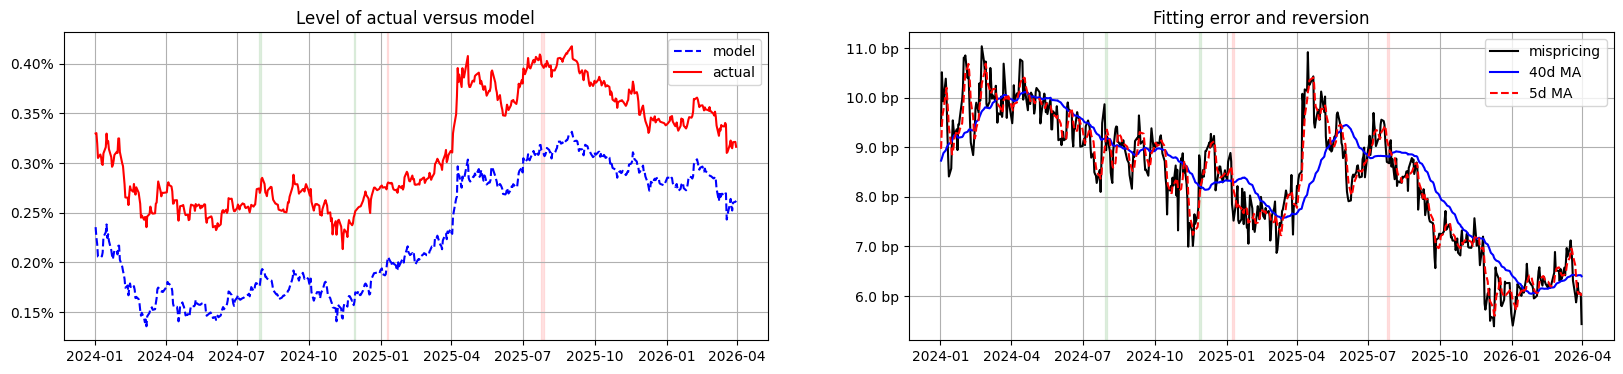

In [44]:
targetSlope = '11s15s'

displayStart = '2024-01-01'

bt = screen.singleItemPerformance(modelSeries=slopeDict['model'][targetSlope],
                                  actualSeries=slopeDict['actual'][targetSlope],
                                  **backtestParams)

print(bt.loc[bt['entry_date'] >= displayStart].to_string())

screen.plotModelVsActual(modelSeries= slopeDict['model'][targetSlope],
                         actualSeries = slopeDict['actual'][targetSlope],
                         backtestDf = bt,
                         shortW = backtestParams['shortW'], longW = backtestParams['longW'], standardW = backtestParams['standardW'], leftPlotBp = False,
                         startDt = backtestParams['startDt'], endDt = None,
                         display_startDt= displayStart, display_endDt=None)

In [45]:
screen.singleItemPerformance(modelSeries= slopeDict['model'][targetSlope],
                             actualSeries = slopeDict['actual'][targetSlope], 
                             **backtestParams)

,entry_date,exit_date,side,entry_actual,exit_actual,entry_misp,exit_misp,entry_signal,exit_signal,entry_z,exit_z,stop,reason,pnl,days,hit
0,2022-05-12,2022-05-17,LONG,0.198474,0.178796,-0.023063,-0.026064,-0.004560,0.000767,2.522453,1.710287,False,take_profit,0.019678,5,True
1,2022-06-20,2022-06-21,LONG,0.182696,0.190760,-0.010884,-0.012351,-0.001240,0.003523,2.033820,1.867435,True,stop_loss,-0.008064,1,False
2,2022-08-18,2022-08-24,SHORT,0.229621,0.204231,0.029108,0.050418,0.000421,-0.006416,-2.041898,0.943584,True,stop_loss,-0.025390,6,False
3,2022-11-23,2022-11-24,LONG,0.167530,0.181748,0.082070,0.088266,-0.000364,0.002650,2.133876,2.772596,True,stop_loss,-0.014218,1,False
4,2023-02-02,2023-02-03,LONG,0.290121,0.292913,0.097306,0.097723,-0.010589,-0.002841,2.812526,2.853185,True,stop_loss,-0.002793,1,False
5,2023-03-29,2023-03-30,SHORT,0.243418,0.232223,0.092991,0.086102,0.011879,0.005732,-2.065175,-2.594060,True,stop_loss,-0.011196,1,False
6,2023-04-25,2023-04-26,LONG,0.232627,0.235798,0.089144,0.090725,-0.016263,-0.013812,2.313300,2.639072,True,stop_loss,-0.003171,1,False
7,2023-04-27,2023-05-02,LONG,0.235372,0.241389,0.094619,0.101187,-0.010636,-0.003578,2.068722,2.970227,True,stop_loss,-0.006018,5,False
8,2023-07-13,2023-07-19,SHORT,0.137464,0.155954,0.113756,0.101879,0.012751,-0.004676,-2.151083,-4.123890,False,take_profit,0.018490,6,True
9,2023-08-09,2023-08-10,LONG,0.168449,0.174319,0.111002,0.111327,-0.007908,-0.006484,2.010408,2.097394,True,stop_loss,-0.005869,1,False


#### 3.4. Attractive butterfly trades right now

In [49]:
pd.concat([flyScreen.loc[flyScreen['zscore'].abs() > 1.5].sort_values('zscore').head(10),
           flyScreen.loc[flyScreen['zscore'].abs() > 1.5].sort_values('zscore').tail(10)])

,model,actual,error,signal,rollMean,rollStd,zscore
10s11s12s,-0.012968,-0.007579,0.005389,0.000524,0.005675,0.000134,-2.140699
9s11s13s,-0.052413,-0.029901,0.022512,0.002233,0.023630,0.000574,-1.947736
8s12s16s,-0.182284,-0.123740,0.058544,0.005242,0.060554,0.001226,-1.638329
8s11s14s,-0.119977,-0.065541,0.054437,0.005579,0.056820,0.001480,-1.610709
20s21s22s,-0.003236,-0.004865,-0.001630,0.000031,-0.001770,0.000093,1.512425
19s21s23s,-0.012995,-0.019570,-0.006576,0.000119,-0.007139,0.000366,1.538933
10s17s24s,-0.277042,-0.350498,-0.073456,-0.003470,-0.082277,0.005644,1.562773
7s16s25s,-0.573331,-0.572465,0.000867,0.005866,-0.007539,0.005378,1.562807
11s17s23s,-0.197714,-0.261888,-0.064174,-0.003457,-0.071490,0.004681,1.562920
12s17s22s,-0.134034,-0.184679,-0.050645,-0.002838,-0.056236,0.003537,1.580629


In [55]:
targetFly = '10s20s30s'

currentPrice = flyScreen.loc[targetFly, 'actual']
targetPrice = flyScreen.loc[targetFly, 'model'] + flyScreen.loc[targetFly, 'rollMean']
stopLossPrice = targetPrice + 2.5 * flyScreen.loc[targetFly, 'rollStd']

print('Current Price: \t', format(currentPrice.round(5) * 100, '.5f'), 'bp')
print('Target Price: \t', format(targetPrice.round(5) * 100, '.5f'), 'bp')
print('Stop Loss: \t', format(stopLossPrice.round(5) * 100, '.5f'), 'bp')

Current Price: 	 -57.06100 bp
Target Price: 	 -58.38200 bp
Stop Loss: 	 -56.98300 bp


   entry_date  exit_date   side  entry_actual  exit_actual  entry_misp  exit_misp  entry_signal  exit_signal   entry_z    exit_z   stop       reason       pnl  days    hit
8  2025-05-02 2025-05-08   LONG     -0.680001    -0.666656   -0.232668  -0.218209     -0.022720    -0.005309  2.075820  3.298481   True    stop_loss -0.013346     6  False
9  2026-01-02 2026-01-06   LONG     -0.595417    -0.612785   -0.148976  -0.165293     -0.002804     0.001494  2.446606  0.029215  False  take_profit  0.017369     4   True
10 2026-02-23 2026-02-25  SHORT     -0.606554    -0.608827   -0.161129  -0.166015      0.002850    -0.000169 -2.017493 -4.225355   True    stop_loss -0.002272     2  False


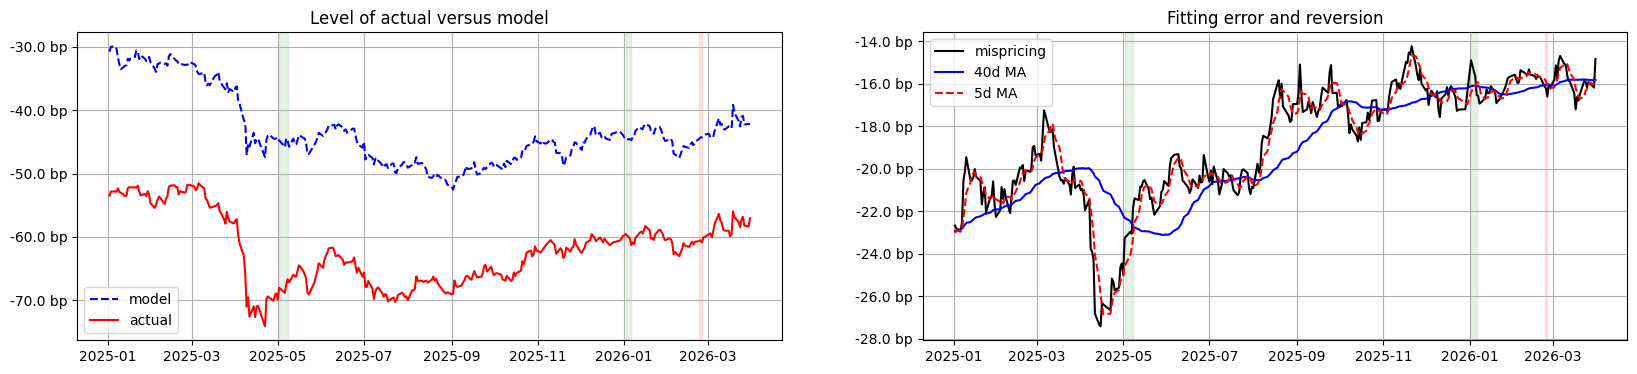

In [ ]:
targetFly = '10s20s30s'

displayStart = '2025-01-01'

bt = screen.singleItemPerformance(modelSeries=flyDict['model'][targetFly],
                                  actualSeries=flyDict['actual'][targetFly],
                                  **backtestParams)

print(bt.loc[bt['entry_date'] >= displayStart].to_string())

screen.plotModelVsActual(modelSeries= flyDict['model'][targetFly],
                         actualSeries = flyDict['actual'][targetFly],
                         backtestDf = bt,
                         shortW = backtestParams['shortW'], longW = backtestParams['longW'], standardW = backtestParams['standardW'], leftPlotBp = True,
                         startDt = backtestParams['startDt'], endDt = None,
                         display_startDt= displayStart, display_endDt=None)

### 4. Time series of the residuals

In [57]:
oosFittingErrors = fittingErrors_2024['2024-01-01':]

/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_88384/822270604.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  ax[1].bar(fittingErrors_2024.columns, oosFittingErrors.apply(lambda x: kpss(x.dropna(),regression='c')[1]));
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_88384/822270604.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  ax[1].bar(fittingErrors_2024.columns, oosFittingErrors.apply(lambda x: kpss(x.dropna(),regression='c')[1]));
/var/folders/6s/ljt_tdhn2332n40p605w9dgr0000gn/T/ipykernel_88384/822270604.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  ax[1].bar(fittingErrors_2024.col

Text(0.5, 1.0, 'PP p-values')

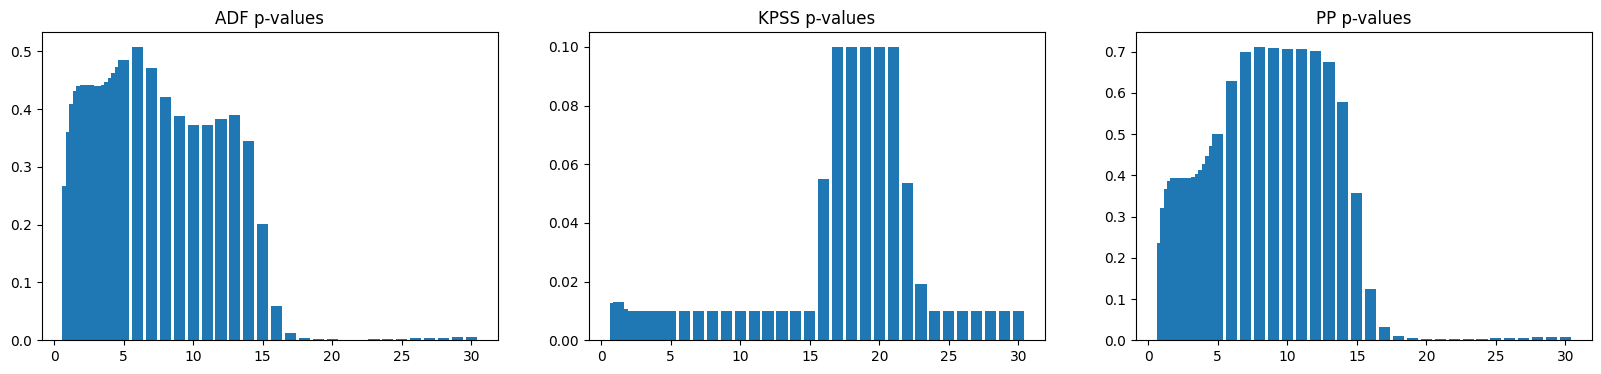

In [58]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (20, 4))
ax[0].bar(fittingErrors_2024.columns, oosFittingErrors.apply(lambda x: adfuller(x.dropna(), autolag = 'BIC', regression = 'c')[1]));
ax[0].set_title('ADF p-values')
ax[1].bar(fittingErrors_2024.columns, oosFittingErrors.apply(lambda x: kpss(x.dropna(),regression='c')[1]));
ax[1].set_title('KPSS p-values')
ax[2].bar(fittingErrors_2024.columns, oosFittingErrors.apply(lambda x: PhillipsPerron(x.dropna(), trend = 'c').pvalue));
ax[2].set_title('PP p-values')

It seems that all tests agree that fitting errors below 15y are nonstationary. Then ADF and PP say that long-end fitting errors are stationary.

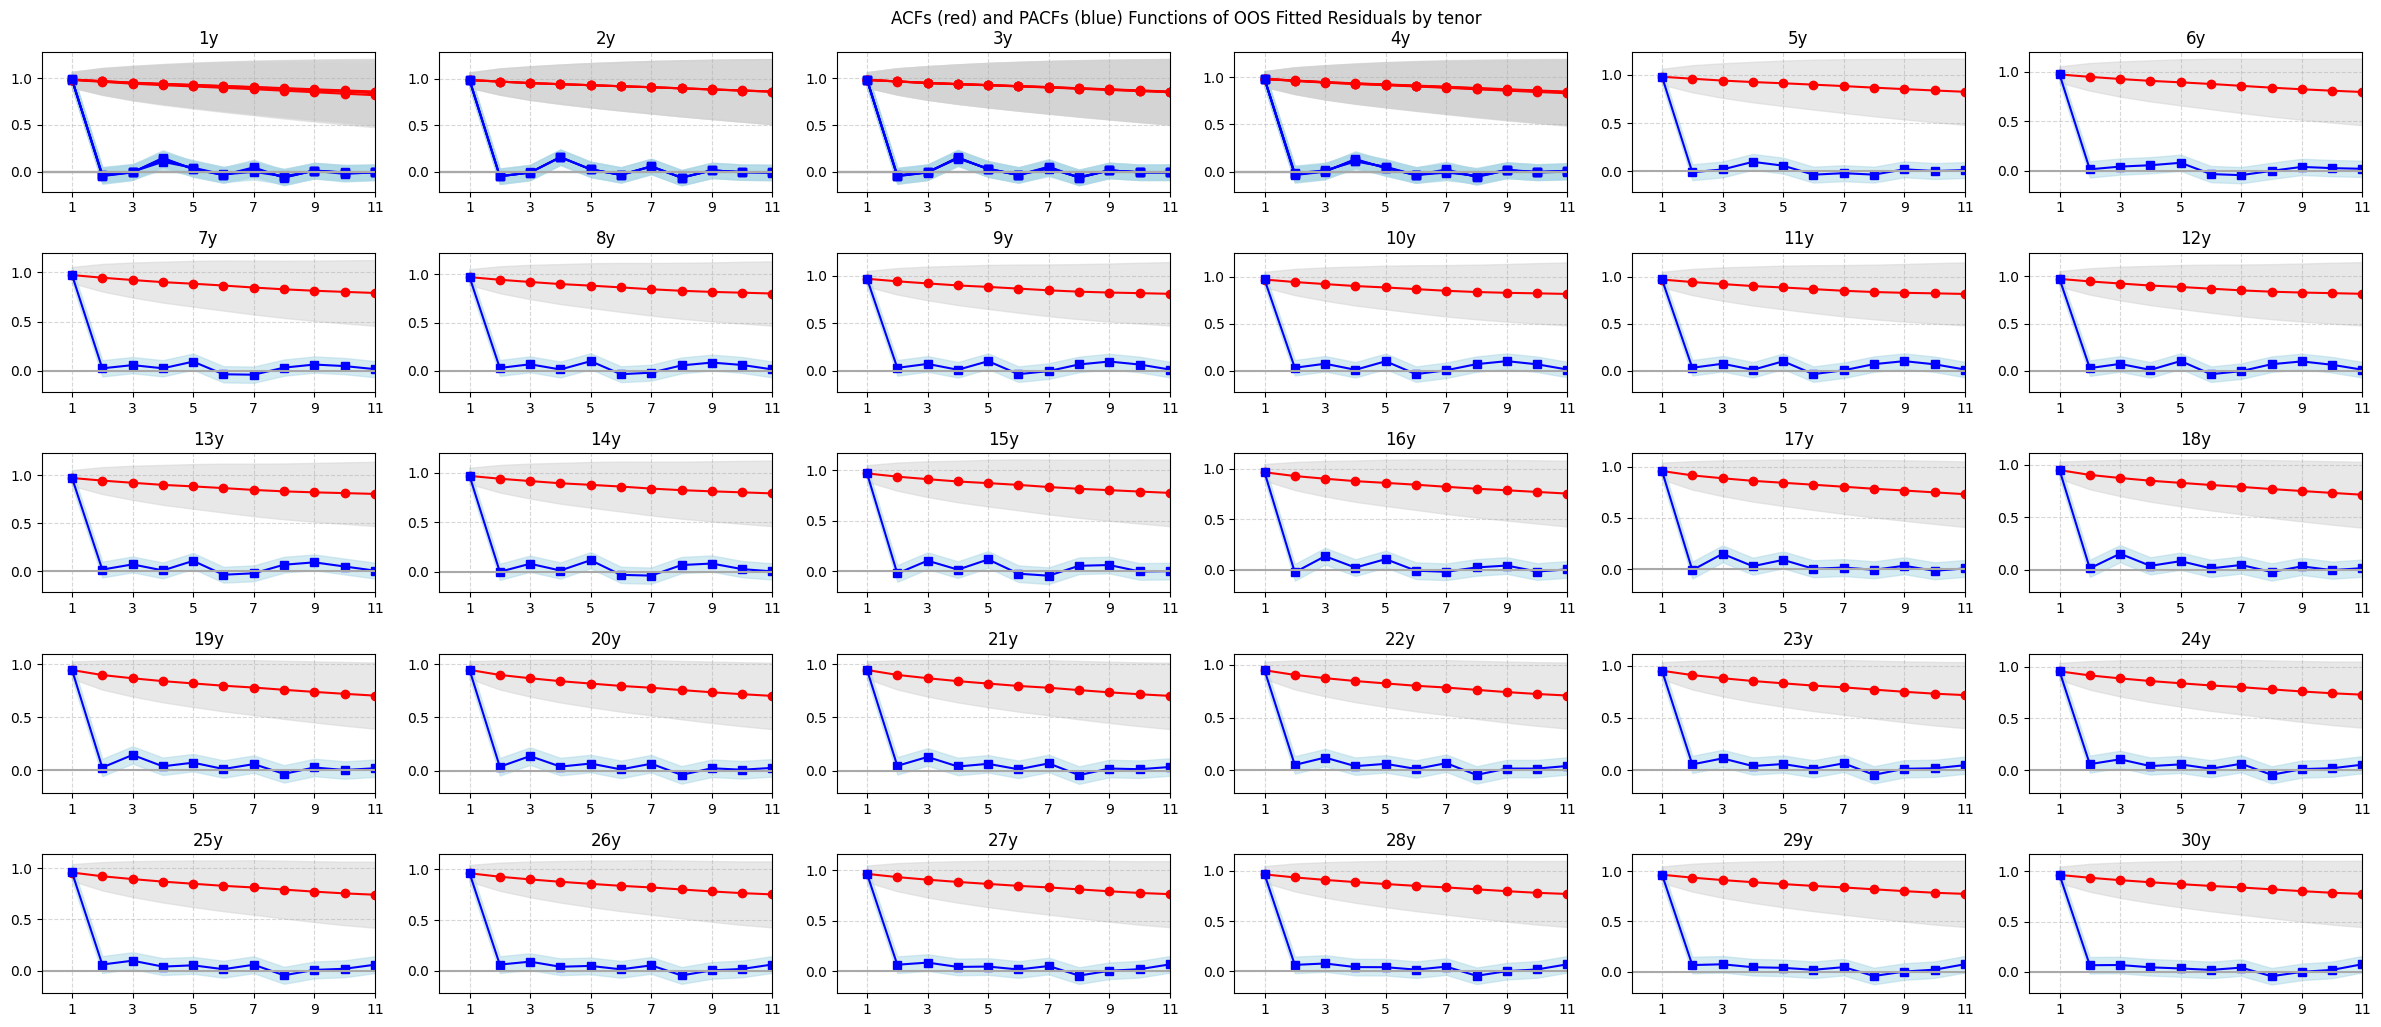

In [59]:
fig, ax = plt.subplots(nrows = 5, ncols = 6, figsize = (24, 14))
ax = ax.flatten()
for tenor in oosFittingErrors.columns:
    sampleAcf, acfCI = acf(oosFittingErrors[tenor].dropna(), alpha = 0.05)
    sampleAcf = sampleAcf[1:]
    samplePacf, pacfCI = pacf(oosFittingErrors[tenor].dropna(), alpha = 0.05)
    samplePacf = samplePacf[1:]
    pacfCI = pacfCI[1:]
    acfCI = acfCI[1:]
    ax[int(tenor-1)].plot(sampleAcf, marker = 'o', color = 'red')
    ax[int(tenor-1)].plot(samplePacf, marker = 's', color = 'blue')
    ax[int(tenor-1)].fill_between(range(len(sampleAcf)), acfCI[:, 0], acfCI[:, 1], color = 'lightgrey', alpha = 0.5)
    ax[int(tenor-1)].fill_between(range(len(samplePacf)), pacfCI[:, 0], pacfCI[:, 1], color = 'lightblue', alpha = 0.5)
    ax[int(tenor-1)].axhline(y = 0, color = 'darkgrey')
    ax[int(tenor-1)].set_title(f'{int(tenor)}y')
    ax[int(tenor-1)].set_xticks(range(0, len(sampleAcf), 2))
    ax[int(tenor-1)].set_xticklabels(range(1, len(sampleAcf)+1, 2))
    ax[int(tenor-1)].set_xlim(-1, 10)
    ax[int(tenor-1)].grid(True, which = 'both', linestyle = '--', alpha = 0.5)

fig.suptitle('ACFs (red) and PACFs (blue) Functions of OOS Fitted Residuals by tenor')
plt.tight_layout(rect=[0, 0.25, 1, 1.0])


In [62]:
autoReg_coefficients = {}
act_halflives = {}
MAXLAG_AR =2
for tenor in oosFittingErrors.columns:
    df = pd.DataFrame()
    df['series'] = oosFittingErrors[tenor]
    for L in range(1, MAXLAG_AR + 1):
        df[f'series.lag{L}'] = df['series'].shift(L)
    df = df.dropna()
    model_ar1 = smf.OLS(endog = df['series'], exog = smf.add_constant(df[['series.lag1']])).fit()
    model = smf.OLS(endog = df['series'], exog = smf.add_constant(df[[f'series.lag{i}' for i in range(1, MAXLAG_AR + 1)]])).fit()
    autoReg_coefficients[tenor] = model_ar1.params['series.lag1']
    phi = model.params.values[1:]
    psiStore = [0 for _ in range(MAXLAG_AR-1)] + [1]
    curr_psi = 1
    while abs(curr_psi) > 0.5:
        curr_psi = sum([phi[i] * psiStore[-1 - i] for i in range(MAXLAG_AR)])
        psiStore.append(curr_psi)
    act_halflives[tenor] = len(psiStore) - MAXLAG_AR - 1

    

Indeed if we model residuals as AR(1), their $\phi$ is very close to 1, and hence they're not the most tradable.

In [63]:
pd.DataFrame([autoReg_coefficients, 
              {key: np.log(0.5)/np.log(abs(value)) for key, value in autoReg_coefficients.items()},
              act_halflives], index = ['AR(1) coefficient', 'AR(1) half-life in days', f'AR({MAXLAG_AR}) actual half-lives']).T

,AR(1) coefficient,AR(1) half-life in days,AR(2) actual half-lives
1.00,0.987708,56.040690,54.0
1.25,0.989673,66.773434,64.0
1.50,0.990542,72.942085,70.0
1.75,0.990922,76.007821,72.0
2.00,0.991078,77.341003,73.0
2.25,0.991131,77.802693,74.0
2.50,0.991135,77.841686,74.0
3.00,0.991078,77.341003,73.0
3.25,0.991030,76.926111,73.0
3.50,0.990971,76.419240,73.0


### 5. Attractive Right Now

#### 5.1 Factor sensitivities of a trade

In [38]:
marketValuePositions = {10: 1 * 10_000_000}

yields = {10: zeroCouponYields[10].iloc[-1]}

screen.factorSensitivity(marketValuePositions=marketValuePositions,
                         yields = yields,
                         pricer = fittedPricer_2024)

,position,market value,mod duration,DV01,short sensitivity,medium sensitivity,long sensitivity,short DV01,medium DV01,long DV01
tenor,,,,,,,,,,
10.0,long,"10,000,000",9.528874,"-9,529",0.049261,0.243233,0.666168,-469,"-2,318","-6,348"
Total,,,,,,,,-469,"-2,318","-6,348"


In [39]:
marketValuePositions = {20: 2 * 10_000_000, 
                        30: -1 * 10_000_000, 
                        10: -1 * 10_000_000}

yields = {20: zeroCouponYields[20].iloc[-1], 
          30: zeroCouponYields[30].iloc[-1], 
          10: zeroCouponYields[10].iloc[-1]}

screen.factorSensitivity(marketValuePositions=marketValuePositions,
                         yields = yields,
                         pricer = fittedPricer_2024)

,position,market value,mod duration,DV01,short sensitivity,medium sensitivity,long sensitivity,short DV01,medium DV01,long DV01
tenor,,,,,,,,,,
20.0,long,"20,000,000",18.944046,"-37,888",0.024631,0.124353,0.745731,-933,"-4,712","-28,254"
30.0,short,"-10,000,000",28.400127,"28,400",0.01642,0.082935,0.734217,466,"2,355","20,852"
10.0,short,"-10,000,000",9.528874,"9,529",0.049261,0.243233,0.666168,469,"2,318","6,348"
Total,,,,,,,,3,-38,"-1,055"
